# Generative Adversarial Network (GAN) on MNIST

A **GAN** pits two networks against each other in a minimax game:
- a **generator** that maps random noise to fake images, trying to fool the discriminator
- a **discriminator** that classifies images as real (from the dataset) or fake (from the generator)

Both networks train simultaneously: the discriminator learns to tell real from fake, while the generator learns to produce images realistic enough to fool it. At convergence the generator should produce samples indistinguishable from real data. Here we build a simple convolutional GAN (DCGAN-style) for MNIST digits, driven by a 100-dimensional latent noise vector.

In [12]:
import os

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.utils import save_image, make_grid

In [13]:
DATA_DIR = os.path.join("..", "data")

In [14]:
# Check if MPS is available
device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using device: {device}")

Using device: mps


In [22]:
# hyperparams
batch_size = 128
num_epochs = 50
z_dimensions = 100

def to_img(x):
    out = 0.5*(x+1)
    out = out.clamp(0, 1)
    out = out.view(-1, 1, 28, 28)
    return out

img_transform = transforms.Compose(
    [
        transforms.ToTensor()
    ]
)

In [23]:
# dataset (MNIST) - reuses DATA_DIR if already downloaded, otherwise fetches it there
dataset = datasets.MNIST(DATA_DIR, transform=img_transform, download=True)
dataloader = DataLoader(dataset, batch_size, shuffle=True)

In [24]:
if not os.path.exists('./dc_img'):
    os.mkdir('./dc_img')

## Model

**Discriminator**: two conv blocks (`1 → 32 → 64` channels, kernel 5, average pooling) followed by a fully-connected head (`3136 → 1024 → 1`) ending in a `Sigmoid` that outputs the probability an image is real.

**Generator**: a linear projection from the 100-dim noise vector to a `56×56` single-channel map, followed by three conv blocks (`1 → 50 → 25 → 1` channels) that refine it down to a `28×28` image, with a final `Tanh` to match the normalized `[-1, 1]` pixel range.

In [25]:
# Discriminator

class Discriminator(nn.Module):
    """Convolutional discriminator that scores 28x28 MNIST images as real or fake."""

    def __init__(self):
        super(Discriminator, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, 5, padding=2),
            nn.LeakyReLU(0.2, True),
            nn.AvgPool2d(2, stride=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 5, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, True),
            nn.AvgPool2d(2, stride=2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64*7*7, 1024),
            nn.LeakyReLU(0.2, True),
            nn.Linear(1024, 1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Return the real/fake probability for each image in the batch."""
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [26]:
# Generator

class Generator(nn.Module):
    def __init__(self, input_size, num_features):
        super(Generator, self).__init__()
        self.fc = nn.Linear(input_size, num_features)
        self.br = nn.Sequential(
            nn.BatchNorm2d(1),
            nn.ReLU(),
        )
        self.downsample1 = nn.Sequential(
            nn.Conv2d(1, 50, 3, stride=1, padding=1),
            nn.BatchNorm2d(50),
            nn.ReLU(True)
        )
        self.downsample2 = nn.Sequential(
            nn.Conv2d(50, 25, 3, stride=1, padding=1),
            nn.BatchNorm2d(25),
            nn.ReLU(True)
        )
        self.downsample3 = nn.Sequential(
            nn.Conv2d(25, 1, 2, stride=2),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), 1, 56, 56)
        x = self.br(x)
        x = self.downsample1(x)
        x = self.downsample2(x)
        x = self.downsample3(x)
        return x

In [27]:
D = Discriminator().to(device)
G = Generator(z_dimensions, 3136).to(device)

# loss
criterion = nn.BCELoss()

# optimizers (betas=(0.5, 0.999) per the DCGAN paper: default beta1=0.9 causes
# oscillation/instability in adversarial training)
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

# fixed noise vector so saved samples can be compared epoch-to-epoch
fixed_noise = torch.randn(64, z_dimensions).to(device)

## Training

Each step alternates two updates: the discriminator is trained on a batch of real images (label smoothed to `0.9`) and a batch of generator-produced fake images (label `0`), then the generator is trained to fool the discriminator by pushing its output toward `1` for those same fakes. Every 10 epochs, samples from a fixed noise vector are saved to `./dc_img/` so generator progress can be compared across epochs.

In [28]:
# Training
train = True

if train:
    for epoch in range(num_epochs):
        for i, (img, _) in enumerate(dataloader):
            num_img = img.size(0)

            # Discriminator
            real_img = img.to(device)
            # one-sided label smoothing (0.9 instead of 1.0) keeps D from getting overconfident
            real_label = torch.full((num_img,), 0.9).to(device)
            fake_label = torch.zeros(num_img).to(device)

            # loss D on real images
            real_out = D(real_img).squeeze(1)
            d_loss_real = criterion(real_out, real_label)
            real_scores = real_out

            # loss G on generated images
            z = torch.randn(num_img, z_dimensions).to(device)
            fake_img = G(z)
            fake_out = D(fake_img).squeeze(1)
            d_loss_fake = criterion(fake_out, fake_label)
            fake_scores = fake_out

            # optim
            d_loss = d_loss_real + d_loss_fake
            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            # train the generator
            z = torch.randn(num_img, z_dimensions).to(device)
            fake_img = G(z)
            output = D(fake_img).squeeze(1)

            # Generator loss uses the hard "real" label (no smoothing) so it gets a full gradient signal
            g_loss = criterion(output, torch.ones(num_img).to(device))
            g_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

            if (i+1) % 100 == 0:
                print("Epoch [{}/{}], d_loss: {:.6f}, g_loss: {:.6f}\tD real: {:.6f}, D fake: {:.6f}".format(
                    epoch, num_epochs, d_loss.item(), g_loss.item(), real_scores.data.mean(), fake_scores.data.mean()
                ))

        if epoch == 0:
            real_images = to_img(real_img.cpu().data)
            save_image(real_images, "./dc_img/real_images.png")

        # save actual generator output (from the fixed noise vector) so progress is visible across epochs
        G.eval()
        with torch.no_grad():
            fake_images = to_img(G(fixed_noise).cpu().data)
        G.train()
        if epoch % 10 == 0:
            save_image(fake_images, "./dc_img/fake_images_{}.png".format(epoch+1))

    torch.save(G.state_dict(), "./generator.pth")
    torch.save(D.state_dict(), "./discriminator.pth")
else:
    # load the weights saved from a previous (or interrupted-but-persisted) training run
    G.load_state_dict(torch.load("./generator.pth", map_location=device))
    D.load_state_dict(torch.load("./discriminator.pth", map_location=device))
    G.eval()
    D.eval()
    print("Loaded pretrained generator and discriminator weights.")

Epoch [0/50], d_loss: 0.385588, g_loss: 4.478451	D real: 0.920646, D fake: 0.036916
Epoch [0/50], d_loss: 0.451299, g_loss: 3.142968	D real: 0.748496, D fake: 0.021315
Epoch [0/50], d_loss: 0.405806, g_loss: 4.074029	D real: 0.868794, D fake: 0.051819
Epoch [0/50], d_loss: 0.398628, g_loss: 3.743815	D real: 0.813861, D fake: 0.017759
Epoch [1/50], d_loss: 4.901711, g_loss: 0.245317	D real: 0.008161, D fake: 0.000024
Epoch [1/50], d_loss: 0.390114, g_loss: 4.312495	D real: 0.849122, D fake: 0.027866
Epoch [1/50], d_loss: 0.395396, g_loss: 3.617723	D real: 0.847314, D fake: 0.029322
Epoch [1/50], d_loss: 0.404878, g_loss: 2.984721	D real: 0.796426, D fake: 0.009916
Epoch [2/50], d_loss: 0.369800, g_loss: 4.292281	D real: 0.826989, D fake: 0.004529
Epoch [2/50], d_loss: 0.426507, g_loss: 4.420420	D real: 0.938935, D fake: 0.066799
Epoch [2/50], d_loss: 0.352111, g_loss: 5.462912	D real: 0.914787, D fake: 0.015568
Epoch [2/50], d_loss: 0.432795, g_loss: 3.721108	D real: 0.931528, D fake: 0

## Results

Sample digits from the trained generator and check how confidently the discriminator tells real MNIST digits apart from generated ones.

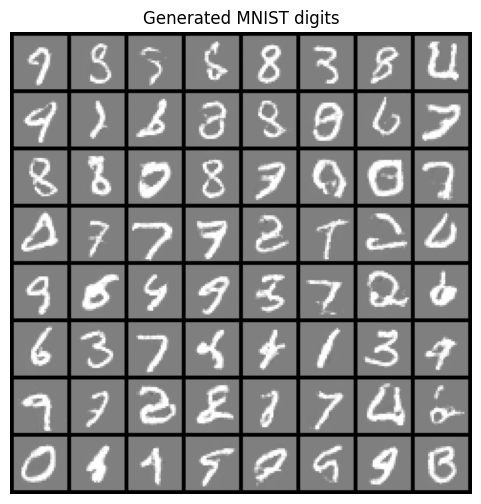

In [29]:
def show_generated_grid(generator: nn.Module, num_samples: int, z_dim: int, device: torch.device) -> None:
    """Sample random noise, generate images, and display them in a grid."""
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(num_samples, z_dim).to(device)
        samples = to_img(generator(noise).cpu())

    grid = make_grid(samples, nrow=8).permute(1, 2, 0)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid, cmap="gray")
    plt.axis("off")
    plt.title("Generated MNIST digits")
    plt.show()

show_generated_grid(G, num_samples=64, z_dim=z_dimensions, device=device)

In [30]:
def average_discriminator_score(discriminator: nn.Module, images: torch.Tensor, device: torch.device) -> float:
    """Return the discriminator's mean predicted probability that a batch of images is real."""
    discriminator.eval()
    with torch.no_grad():
        scores = discriminator(images.to(device)).squeeze(1)
    return scores.mean().item()

real_batch, _ = next(iter(dataloader))
with torch.no_grad():
    fake_batch = G(torch.randn(real_batch.size(0), z_dimensions).to(device))

real_score = average_discriminator_score(D, real_batch, device)
fake_score = average_discriminator_score(D, fake_batch, device)

print(f"D(real images): {real_score:.4f}")
print(f"D(fake images): {fake_score:.4f}")

D(real images): 0.6358
D(fake images): 0.0750
